# Implémentation de l'algorithme ABC-Reject

Ce notebook implémente ABC-Reject, l'algorithme de référence de l'article *Component-wise approximate Bayesian computation via Gibbs-like steps* (Clarté et al., 2021).

L'objectif : estimer les 20 paramètres d'un modèle MA(2) hiérarchique, et mesurer à quel point ABC-Reject échoue là où ABC-Gibbs réussit.

---

## Le modèle MA(2) hiérarchique

Tu observes $n$ séries temporelles $x_1, \ldots, x_n$, chacune de longueur $T$ :

$$x_j(t) = y_t + \mu_{j,1}\, y_{t-1} + \mu_{j,2}\, y_{t-2}, \qquad y_t \sim \mathcal{N}(0, \sigma_j^2)$$

- $y_t$ est un bruit blanc gaussien tiré indépendamment à chaque pas
- $\mu_j = (\mu_{j,1}, \mu_{j,2})$ contrôle la dépendance temporelle : si $\mu_{j,1}$ est grand, les observations consécutives sont corrélées
- $x_j(t)$ est une combinaison linéaire des trois dernières innovations

Le modèle s'appelle MA(2) parce que la mémoire s'arrête à 2 pas dans le passé. Conséquence directe : $x_j(t)$ et $x_j(t+3)$ sont indépendants, car ils ne partagent aucune innovation commune. Cette propriété est centrale pour les statistiques résumées.

### Pourquoi la vraisemblance est difficile à calculer

La densité jointe de $(x_j(1), \ldots, x_j(T))$ est gaussienne multivariée avec une matrice de covariance bande. Pour $T=5$, cette matrice ressemble à :

$$\Sigma = \begin{pmatrix} c_0 & c_1 & c_2 & 0 & 0 \\ c_1 & c_0 & c_1 & c_2 & 0 \\ c_2 & c_1 & c_0 & c_1 & c_2 \\ 0 & c_2 & c_1 & c_0 & c_1 \\ 0 & 0 & c_2 & c_1 & c_0 \end{pmatrix}$$

Seules les 5 diagonales centrales sont non nulles. Les zéros viennent du fait que deux observations séparées de 3 pas ou plus ne partagent aucune innovation. Pour $T=100$, l'inversion de cette matrice $100 \times 100$ est coûteuse à répéter des millions de fois. Simuler une trajectoire, en revanche, ne coûte que $T$ additions.

### La structure hiérarchique

Les $n$ séries partagent des hyperparamètres communs. Pour $j = 1, \ldots, n$ :

$$( \beta_{j,1}, \beta_{j,2}, 1-\beta_{j,1}-\beta_{j,2}) \sim \text{Dir}(\alpha), \qquad \mu_j = (\beta_{j,1} - \beta_{j,2},\; 2(\beta_{j,1}+\beta_{j,2})-1)$$
$$\sigma_j^2 \sim \text{IG}(\varsigma_1, \varsigma_2)$$

Hyperpriors : $\alpha \sim \text{Exp}(1)^{\otimes 3}$, $\;\varsigma \sim \text{Exp}(1)^{\otimes 2}$.

Au total : $3n + 5 = 20$ paramètres pour $n=5$ séries. C'est cette dimension qui pose problème à ABC-Reject.

---

## ABC : le principe

Puisqu'on ne peut pas évaluer la vraisemblance, on contourne le problème :

1. Tirer $\theta \sim \pi(\theta)$ depuis le prior
2. Simuler $x^{\text{sim}} \sim f(\cdot \mid \theta)$
3. Comparer des statistiques résumées $s(x^{\text{sim}})$ et $s(x^\star)$
4. Accepter $\theta$ si $\delta(s(x^{\text{sim}}), s(x^\star)) < \varepsilon$

### Pourquoi ne pas comparer les séries directement

Si tu compares $x^{\text{sim}}$ et $x^\star$ avec la distance euclidienne dans $\mathbb{R}^{100}$, tu obtiens une distance qui ne dépend presque pas de $\theta$. Voici pourquoi.

Même avec le bon $\theta^\star$, les deux séries utilisent des innovations $y_t$ différentes et indépendantes. On peut montrer que :

$$\mathbb{E}\left[\|x^{\text{sim}} - x^\star\|_2^2\right] = 2T\sigma^2(1 + \mu_1^2 + \mu_2^2)$$

Ce terme croît avec $T$, indépendamment de la qualité de $\theta$. Pour $T=100$, la distance euclidienne entre deux séries avec le bon paramètre est déjà de l'ordre de $\sqrt{200} \approx 14$. Elle est quasi-identique avec un mauvais paramètre. La distance brute ne t'informe pas sur $\theta$.

### La malédiction de la dimension

Le taux d'acceptation d'ABC décroît exponentiellement avec la dimension $d$ des statistiques :

$$P(\delta < \varepsilon) \approx \varepsilon^d$$

- $d=2$, $\varepsilon=0.1$ : probabilité $\approx 0.01$ — acceptable
- $d=100$ (données brutes) : probabilité $\approx 10^{-100}$ — impossible

---

## ABC-Reject : l'algorithme

Pour $i = 1$ à $N_{\text{tot}}$ :

1. Tirer $\theta^{(i)} \sim \pi(\theta)$ — tous les hyperparamètres $\alpha, \varsigma$ puis $\mu_j, \sigma_j^2$
2. Simuler $x^{(i)} \sim f(\cdot \mid \theta^{(i)})$ — $n$ séries MA(2) de longueur $T$
3. Calculer $\delta^{(i)} = \delta(x^{(i)}, x^\star)$ — la distance globale normalisée

Retourner les $N$ paramètres avec les $N$ plus petites distances. Le seuil effectif $\varepsilon^\star$ est le $N$-ième plus petite distance parmi les $N_{\text{tot}}$.

On retire $\alpha$ et $\varsigma$ à chaque itération car ce sont des paramètres inconnus du modèle, pas des constantes fixées. Les valeurs $\alpha=(1,2,3)$ et $\varsigma=(1,1)$ sont les vraies valeurs qui ont généré $x^\star$ — les utiliser directement reviendrait à tricher.

| | ABC-Reject | ABC-Gibbs |
|---|---|---|
| Mise à jour | Tous les 20 paramètres ensemble | Un paramètre à la fois |
| Dimension du problème | 20 | 1 ou 2 |
| Type | Monte Carlo indépendant | Chaîne de Markov |
| Budget papier | $1.1 \times 10^6$ simulations | $5.5 \times 10^6$ simulations |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma, gaussian_kde
import time
import warnings
warnings.filterwarnings('ignore')

## Paramètres globaux

Paramètres de la Section 10.2 du supplément :
- $n=5$ séries, $T=100$ points, $\alpha=(1,2,3)$, $\varsigma=(1,1)$
- Budget : $N_{\text{tot}} = 1\,100\,000$, $N = 1\,000$ échantillons retenus

Le calcul prend 2 à 4 heures sur CPU. Mets `N_TOT = 50_000` pour un test rapide en 10 minutes.

In [ ]:
SEED  = 42
T     = 100
n     = 5
alpha = [1., 2., 3.]
zeta  = [1., 1.]

# Mets N_TOT = 50_000 pour un test rapide
N_TOT  = 50 000
N_KEEP = 1_000

print(f"Modèle : n={n} séries, T={T}, dim(θ) = 3n+5 = {3*n+5}")
print(f"Budget : N_tot={N_TOT:,}, N={N_KEEP}")

Modèle : n=5 séries, T=100, dim(θ) = 3n+5 = 20
Budget : N_tot=1,100,000, N=1000


## Simulation du modèle

### La loi Inverse-Gamma IG($a$, $b$)

Si $X \sim \text{Gamma}(a, b)$ alors $1/X \sim \text{IG}(a, b)$. Sa densité :

$$f(x) = \frac{b^a}{\Gamma(a)} x^{-(a+1)} e^{-b/x}, \qquad x > 0$$

$a > 0$ contrôle la forme, $b > 0$ contrôle l'échelle. L'espérance vaut $b/(a-1)$ pour $a>1$. Avec $\varsigma=(1,1)$, les $\sigma^2$ typiques sont entre 1 et 5. On l'utilise parce que c'est le prior conjugué d'une variance gaussienne : si $\sigma^2 \sim \text{IG}(a,b)$, la posterior sur $\sigma^2$ est encore une IG.

Le papier utilise $\varsigma \sim C_+^{\otimes 2}$ (demi-Cauchy). La demi-Cauchy génère des valeurs de $\varsigma_1$ proches de 0, ce qui fait tendre $\sigma^2 \to \infty$ et cause des overflows numériques en Python. On utilise $\text{Exp}(1)$ à la place. Les deux priors sont non-informatifs sur $\mathbb{R}^+$. La différence sur la posterior est négligeable avec $n=5$ séries et $T=100$ points.

### La transformation $\beta \to \mu$

On veut tirer $\mu_j$ dans la région de stationnarité du MA(2) :

$$\mathcal{M}_2 = \{(\mu_1, \mu_2) : |\mu_2| < 1,\; \mu_2 + \mu_1 > -1,\; \mu_2 - \mu_1 > -1\}$$

Ces trois contraintes définissent un triangle dans $\mathbb{R}^2$. La stationnarité garantit que la série ne diverge pas et que ses autocorrélations sont bien définies.

On tire $(\beta_1, \beta_2, \beta_3) \sim \text{Dir}(\alpha)$ avec $\beta_1 + \beta_2 + \beta_3 = 1$, $\beta_k > 0$, puis :

$$\mu_1 = \beta_1 - \beta_2, \qquad \mu_2 = 2(\beta_1 + \beta_2) - 1$$

Les trois conditions de $\mathcal{M}_2$ sont automatiquement satisfaites pour tout tirage Dirichlet :
- $|\mu_2| < 1$ : car $\beta_3 > 0$ implique $0 < \beta_1+\beta_2 < 1$, donc $-1 < 2(\beta_1+\beta_2)-1 < 1$
- $\mu_2 + \mu_1 = 3\beta_1 + \beta_2 - 1 > -1$ car $\beta_1, \beta_2 > 0$
- $\mu_2 - \mu_1 = \beta_1 + 3\beta_2 - 1 > -1$ pour la même raison

C'est une bijection affine entre le simplexe et le triangle $\mathcal{M}_2$.

In [3]:
def sample_mu(alpha, rng):
    """
    Tire mu depuis Dirichlet(alpha) puis applique la transformation
    beta -> mu qui garantit (mu1, mu2) dans la région de stationnarité M_2.
    """
    beta   = rng.dirichlet(alpha)
    b1, b2 = beta[0], beta[1]
    return np.array([b1 - b2, 2*(b1 + b2) - 1])


def sample_sigma2(zeta, rng):
    """
    Tire sigma² ~ IG(zeta[0], zeta[1]).
    Clip à 100 : des valeurs extrêmes de zeta[0] proches de 0
    peuvent donner sigma² >> 100. Avec les vrais paramètres,
    sigma² est de l'ordre de 1 à 5 — le clip ne biaise pas l'inférence.
    """
    sigma2 = invgamma.rvs(zeta[0], scale=zeta[1], random_state=rng)
    return min(float(sigma2), 100.0)


def sample_hyperparams(rng):
    """
    Tire les hyperparamètres depuis leurs priors :
      alpha ~ Exp(1)^3
      zeta  ~ Exp(1)^2
    Le papier utilise zeta ~ C+^2 (demi-Cauchy), remplacée ici
    par Exp(1) pour stabilité numérique (voir note dans la cellule précédente).
    """
    alpha_s = rng.exponential(scale=1.0, size=3)
    zeta_s  = rng.exponential(scale=1.0, size=2)
    return alpha_s, zeta_s


def simulate_ma2(mu, sigma2, T, rng):
    """
    Simule une série MA(2) de longueur T.
    x(t) = y_{t+2} + mu[0]*y_{t+1} + mu[1]*y_t,  y_t ~ N(0, sigma2)
    On génère T+2 innovations pour avoir accès aux lags 1 et 2
    dès le premier pas de temps.
    """
    sig = np.sqrt(sigma2)
    y   = rng.normal(0, sig, T + 2)
    return np.array([y[t+2] + mu[0]*y[t+1] + mu[1]*y[t] for t in range(T)])


def generate_data(n, T, alpha, zeta, rng=None):
    """
    Génère n séries MA(2) hiérarchiques de longueur T.
    Retourne (x_list, mu_list, sigma2_list).
    """
    if rng is None:
        rng = np.random.default_rng(42)
    x_list, mu_list, sigma2_list = [], [], []
    for _ in range(n):
        mu     = sample_mu(alpha, rng)
        sigma2 = sample_sigma2(zeta, rng)
        x      = simulate_ma2(mu, sigma2, T, rng)
        x_list.append(x)
        mu_list.append(mu)
        sigma2_list.append(sigma2)
    return x_list, mu_list, sigma2_list

## Statistiques résumées

### Statistique suffisante, quasi-suffisante, injective : ce que ça veut dire

Une statistique $s(x)$ est **suffisante** pour $\theta$ si elle capture toute l'information des données sur $\theta$. Formellement : la distribution de $x$ conditionnellement à $s(x)$ ne dépend pas de $\theta$. Connaître $s(x)$ est aussi informatif que connaître $x$ entier.

En pratique, une statistique parfaitement suffisante de petite dimension n'existe généralement pas. On parle de statistique **quasi-suffisante** quand elle capture l'essentiel de l'information avec une perte faible. Un résultat théorique de Fearnhead et Prangle (2012) dit que la dimension de $s$ doit être égale à la dimension de $\theta$ — ni plus (le taux d'acceptation s'effondre), ni moins (on perd de l'information).

Une statistique est **injective** si $s(\theta_1) = s(\theta_2) \implies \theta_1 = \theta_2$. Autrement dit : deux paramètres différents donnent forcément deux valeurs de statistique différentes. Sans injectivité, ABC ne peut pas distinguer deux paramètres différents — l'inférence est impossible.

Pour le MA(2), les autocorrélations théoriques valent :

$$\rho_1(\mu) = \frac{\mu_1(1+\mu_2)}{1+\mu_1^2+\mu_2^2}, \qquad \rho_2(\mu) = \frac{\mu_2}{1+\mu_1^2+\mu_2^2}$$

La fonction $\mu \mapsto (\rho_1(\mu), \rho_2(\mu))$ est injective sur $\mathcal{M}_2$ : deux paramètres $\mu \neq \mu'$ donnent toujours $(\rho_1, \rho_2) \neq (\rho_1', \rho_2')$. Les autocorrélations empiriques $(\hat{\rho}_1, \hat{\rho}_2)$ forment donc une statistique quasi-suffisante pour $\mu$.

### Distance $w(x_j)$ pour $\mu_j$

$$w(x_j) = \sqrt{(\hat{\rho}_1(x_j^{\text{sim}}) - \hat{\rho}_1(x_j^\star))^2 + (\hat{\rho}_2(x_j^{\text{sim}}) - \hat{\rho}_2(x_j^\star))^2}$$

L'autocorrélation empirique au lag $k$ :
$$\hat{\rho}_k = \frac{\sum_{t=1}^{T-k}(x_t - \bar{x})(x_{t+k} - \bar{x})}{\sum_{t=1}^{T}(x_t - \bar{x})^2}$$

Le `+ 1e-12` au dénominateur évite une division par zéro si la série est constante. Cela arrive lors de simulations pathologiques depuis le prior (sigma² très grand). On retourne alors 0 au lieu de `NaN`.

### Distance $v(x_j)$ pour $\sigma_j^2$

$$v(x_j) = \left|\frac{1}{M}\sum_{t=1}^{M}(x_j(3t) - \bar{x}_j^{\text{thin}})^2 - \frac{1}{M}\sum_{t=1}^{M}(x_j^\star(3t) - \bar{x}_j^{\star\,\text{thin}})^2\right|$$

avec $M = \lfloor T/3 \rfloor$. Les observations $x(3), x(6), x(9), \ldots$ sont indépendantes (propriété MA(2) rappelée en introduction), donc elles forment un échantillon iid de variance $\sigma^2(1+\mu_1^2+\mu_2^2)$. Cette variance est quasi-suffisante pour $\sigma^2$.

### Distance globale $\delta(x)$ et calibration des quantiles

$$\delta(x) = \sum_{j=1}^{n} \left(\frac{w(x_j)}{q_j} + \frac{v(x_j)}{q'_j}\right)$$

Sans les dénominateurs $q_j$ et $q'_j$, $w$ et $v$ ne sont pas comparables :
- $w$ est une distance entre autocorrélations dans $[-1,1]$ : valeurs typiques entre 0.1 et 0.5
- $v$ est une différence de variances : valeurs typiques 10 à 100 fois plus grandes

Sans normalisation, $\delta$ est entièrement dominé par $v$. Les autocorrélations n'influencent plus les acceptations. On estime donc $q_j = Q_{0.1\%}(w_j)$ et $q'_j = Q_{0.1\%}(v_j)$ sous le prior. Après normalisation, $w/q_j$ et $v/q'_j$ ont des distributions similaires et contribuent à parts égales.

On choisit le quantile 0.1% plutôt que la moyenne ou l'écart-type parce que les distributions de $w$ et $v$ ont des queues lourdes — leur moyenne et écart-type sont instables. Le quantile 0.1% est robuste et capture l'échelle des petites distances qui nous intéressent pour l'acceptation.

In [4]:
def autocorr(x, lag):
    """
    Autocorrélation empirique au lag donné.
    Mesure la corrélation linéaire entre x(t) et x(t+lag).
    Le +1e-12 au dénominateur évite une division par zéro si la
    série est constante (simulation pathologique depuis le prior).
    """
    xc = x - np.mean(x)
    return np.sum(xc[:len(x)-lag] * xc[lag:]) / (np.sum(xc**2) + 1e-12)


def compute_w(x_sim, x_obs_j):
    """
    Distance w entre les autocorrélations lags 1 et 2 de x_sim et x_obs_j.
    Quasi-suffisante pour mu_j : rho1 et rho2 sont des fonctions injectives
    de (mu1, mu2) sur M_2, donc w=0 implique mu_sim = mu_obs.
    """
    d1 = autocorr(x_sim, 1) - autocorr(x_obs_j, 1)
    d2 = autocorr(x_sim, 2) - autocorr(x_obs_j, 2)
    return np.sqrt(d1**2 + d2**2)


def compute_v(x_sim, x_obs_j):
    """
    Distance v entre les variances des observations espacées de 3 pas.
    x(t) et x(t+3) sont indépendants dans MA(2) : x(3), x(6), ...
    forment un échantillon iid de variance sigma²(1+mu1²+mu2²).
    Quasi-suffisante pour sigma².
    """
    M   = T // 3
    idx = np.arange(1, M + 1) * 3 - 1
    return abs(np.var(x_sim[idx]) - np.var(x_obs_j[idx]))


def delta_global(x_sim_list, x_obs_list, q_w, q_v):
    """
    Distance globale delta(x) normalisée — Équation (4) du papier.
    Somme sur les n séries de w/q_w + v/q_v.
    Retourne np.inf si une valeur n'est pas finie (simulation rejetée).
    """
    total = 0.0
    for j in range(n):
        w_j = compute_w(x_sim_list[j], x_obs_list[j])
        v_j = compute_v(x_sim_list[j], x_obs_list[j])
        if not np.isfinite(w_j) or not np.isfinite(v_j):
            return np.inf
        total += w_j / (q_w[j] + 1e-12) + v_j / (q_v[j] + 1e-12)
    return total

## Données observées $x^\star$

Vrais paramètres :
  Série 1 : mu = [ 0.231 -0.193],  sigma² = 40.519
  Série 2 : mu = [-0.041 -0.758],  sigma² = 6.461
  Série 3 : mu = [-0.395  0.521],  sigma² = 1.699
  Série 4 : mu = [-0.044  0.345],  sigma² = 4.504
  Série 5 : mu = [0.638 0.431],  sigma² = 49.566


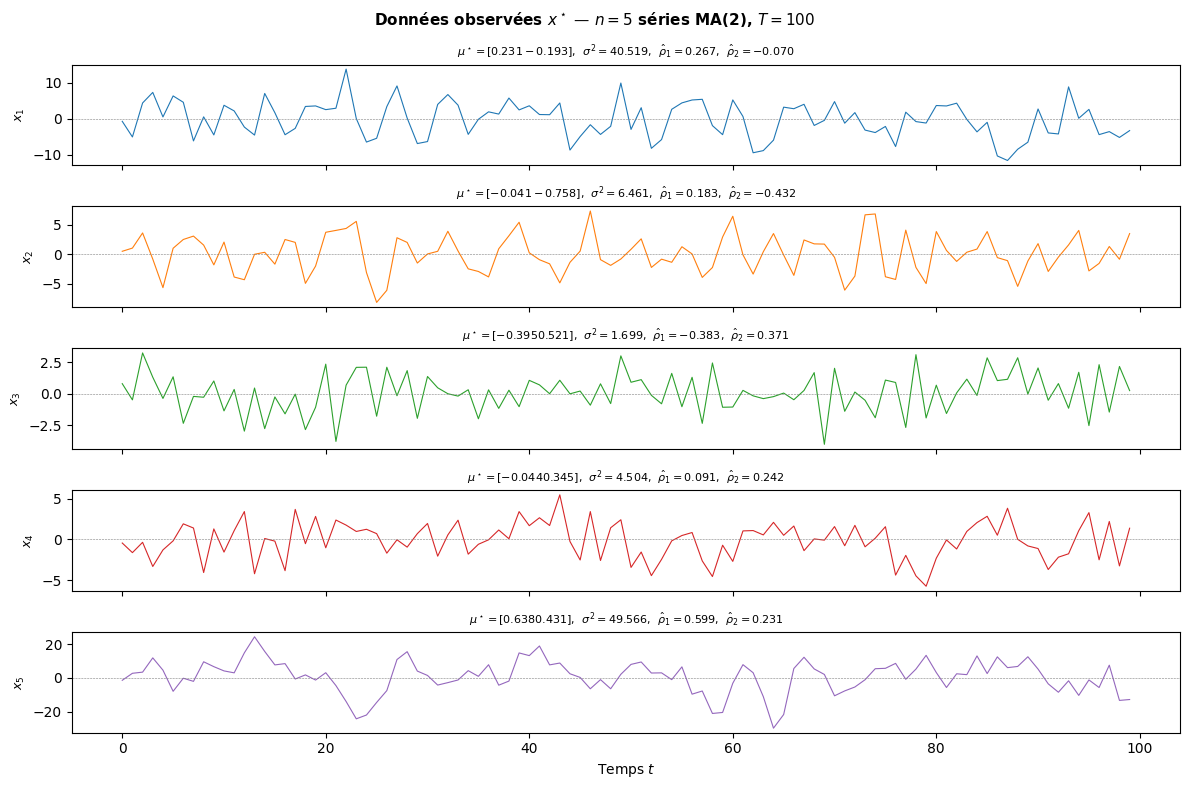

In [5]:
rng_data = np.random.default_rng(SEED)
x_obs, mu_true, sigma2_true = generate_data(n, T, alpha, zeta, rng_data)

print("Vrais paramètres :")
for j in range(n):
    print(f"  Série {j+1} : mu = {np.array(mu_true[j]).round(3)},  "
          f"sigma² = {sigma2_true[j]:.3f}")

fig, axes = plt.subplots(n, 1, figsize=(12, 8), sharex=True)
for j in range(n):
    axes[j].plot(x_obs[j], color=f'C{j}', linewidth=0.8)
    axes[j].axhline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[j].set_ylabel(f'$x_{j+1}$', fontsize=9)
    r1 = autocorr(x_obs[j], 1)
    r2 = autocorr(x_obs[j], 2)
    axes[j].set_title(
        rf'$\mu^\star = {np.array(mu_true[j]).round(3)}$,  '
        rf'$\sigma^2 = {sigma2_true[j]:.3f}$,  '
        rf'$\hat{{\rho}}_1 = {r1:.3f}$,  $\hat{{\rho}}_2 = {r2:.3f}$',
        fontsize=8)
axes[-1].set_xlabel('Temps $t$', fontsize=10)
fig.suptitle(r"Données observées $x^\star$ — $n=5$ séries MA(2), $T=100$",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_donnees_observees.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibration des quantiles $q_j$ et $q'_j$

On simule $N_{\text{cal}} = 10\,000$ jeux de paramètres depuis le prior complet pour estimer les distributions de $w$ et $v$. On prend ensuite le quantile 0.1% de chaque distribution comme normalisateur. On utilise `nanquantile` pour ignorer les rares `NaN` sans interrompre le calcul.

Calibration sur 10,000 simulations...
  Terminé en 16.6s

Quantiles de normalisation (Q 0.1%) :
  Série 1 : q_w = 0.02334,  q_v = 0.15180
  Série 2 : q_w = 0.03331,  q_v = 0.05489
  Série 3 : q_w = 0.02111,  q_v = 0.00906
  Série 4 : q_w = 0.03974,  q_v = 0.01612
  Série 5 : q_w = 0.01116,  q_v = 0.26321


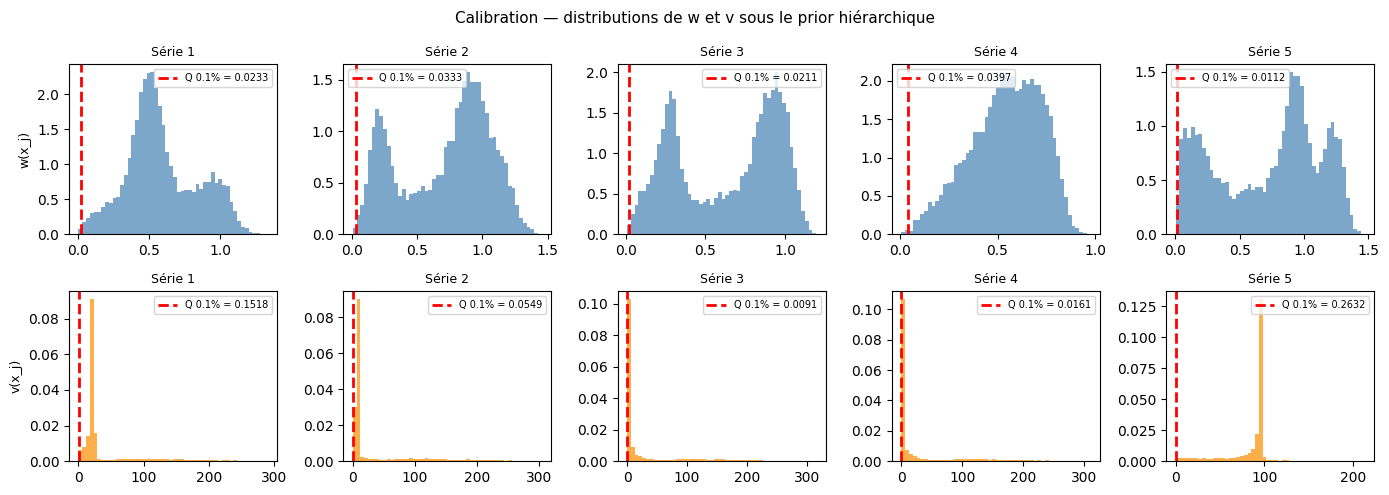

Lecture des graphiques :
  w (ligne du haut) : plusieurs modes car les mu tirés depuis le prior
  sont dispersés sur tout le triangle M_2.
  v (ligne du bas) : plus étalée car sigma² varie beaucoup sous le prior.
  Le seuil rouge est le quantile 0.1% : seulement 1 tirage sur 1000
  donne une distance inférieure à ce seuil.


In [6]:
N_CAL   = 10_000
rng_cal = np.random.default_rng(SEED + 1)

print(f"Calibration sur {N_CAL:,} simulations...")
t0 = time.perf_counter()

w_cal = np.zeros((N_CAL, n))
v_cal = np.zeros((N_CAL, n))

for i in range(N_CAL):
    alpha_i, zeta_i = sample_hyperparams(rng_cal)
    x_sim_i, _, _   = generate_data(n, T, alpha_i, zeta_i, rng_cal)
    for j in range(n):
        w_cal[i, j] = compute_w(x_sim_i[j], x_obs[j])
        v_cal[i, j] = compute_v(x_sim_i[j], x_obs[j])

print(f"  Terminé en {time.perf_counter()-t0:.1f}s")

q_w = np.nanquantile(w_cal, 0.001, axis=0)
q_v = np.nanquantile(v_cal, 0.001, axis=0)

print("\nQuantiles de normalisation (Q 0.1%) :")
for j in range(n):
    print(f"  Série {j+1} : q_w = {q_w[j]:.5f},  q_v = {q_v[j]:.5f}")

fig, axes = plt.subplots(2, n, figsize=(14, 5))
for j in range(n):
    for row, (data, qval, color, ylabel) in enumerate([
        (w_cal[:, j], q_w[j], 'steelblue',  'w(x_j)'),
        (v_cal[:, j], q_v[j], 'darkorange', 'v(x_j)')
    ]):
        ax = axes[row, j]
        finite = data[np.isfinite(data)]
        if row == 1:  # couper les outliers de v pour la lisibilité
            finite = finite[finite <= np.percentile(finite, 99)]
        ax.hist(finite, bins=50, density=True, color=color, alpha=0.7)
        ax.axvline(qval, color='red', lw=2, linestyle='--',
                   label=f'Q 0.1% = {qval:.4f}')
        ax.set_title(f'Série {j+1}', fontsize=9)
        ax.legend(fontsize=7)
        if j == 0:
            ax.set_ylabel(ylabel, fontsize=9)

fig.suptitle('Calibration — distributions de w et v sous le prior hiérarchique', fontsize=11)
plt.tight_layout()
plt.savefig('fig_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print("Lecture des graphiques :")
print("  w (ligne du haut) : plusieurs modes car les mu tirés depuis le prior")
print("  sont dispersés sur tout le triangle M_2.")
print("  v (ligne du bas) : plus étalée car sigma² varie beaucoup sous le prior.")
print("  Le seuil rouge est le quantile 0.1% : seulement 1 tirage sur 1000")
print("  donne une distance inférieure à ce seuil.")

## ABC-Reject

In [7]:
def abc_reject(x_obs, q_w, q_v, N_tot, N_keep, seed,
               verbose=True, print_every=100_000):
    """
    ABC-Reject sur le modèle MA(2) hiérarchique.

    Paramètres
    ----------
    x_obs    : liste de n arrays (T,)
    q_w, q_v : arrays (n,) — quantiles de normalisation
    N_tot    : budget total de simulations
    N_keep   : taille de l'échantillon posterior retenu
    seed     : graine

    Retourne
    --------
    dict : alphas, zetas, mus, sigma2s, distances,
           epsilon, cpu_time, n_simulations, acceptance_rate
    """
    rng_abc     = np.random.default_rng(seed)
    alphas_all  = np.zeros((N_tot, 3))
    zetas_all   = np.zeros((N_tot, 2))
    mus_all     = np.zeros((N_tot, n, 2))
    sigma2s_all = np.zeros((N_tot, n))
    dists_all   = np.full(N_tot, np.inf)

    t0 = time.perf_counter()

    for i in range(N_tot):
        alpha_i, zeta_i = sample_hyperparams(rng_abc)
        x_sim_i, mu_i, sigma2_i = generate_data(n, T, alpha_i, zeta_i, rng_abc)
        dists_all[i]   = delta_global(x_sim_i, x_obs, q_w, q_v)
        alphas_all[i]  = alpha_i
        zetas_all[i]   = zeta_i
        mus_all[i]     = np.array(mu_i)
        sigma2s_all[i] = np.array(sigma2_i)

        if verbose and (i + 1) % print_every == 0:
            el  = time.perf_counter() - t0
            ok  = np.isfinite(dists_all[:i+1])
            eps = np.sort(dists_all[:i+1][ok])[min(N_keep-1, ok.sum()-1)] \
                  if ok.sum() >= N_keep else np.nan
            print(f"  [{i+1:>9,}/{N_tot:,}]  "
                  f"ε = {eps:.2f}  "
                  f"{(i+1)/el:.0f} sim/s  "
                  f"ETA = {int((N_tot-i-1)/((i+1)/el))}s")

    cpu = time.perf_counter() - t0
    idx = np.argsort(dists_all)[:N_keep]
    eps = dists_all[idx[-1]]

    print(f"\nSimulations valides : {np.sum(np.isfinite(dists_all)):,}/{N_tot:,}")
    print(f"ε effectif          : {eps:.4f}")
    print(f"Taux d'acceptation  : {N_keep/N_tot:.4%}")
    print(f"Temps CPU           : {cpu:.1f}s  ({N_tot/cpu:.0f} sim/s)")

    return dict(
        alphas          = alphas_all[idx],
        zetas           = zetas_all[idx],
        mus             = mus_all[idx],
        sigma2s         = sigma2s_all[idx],
        distances       = dists_all[idx],
        all_distances   = dists_all,
        epsilon         = eps,
        cpu_time        = cpu,
        n_simulations   = N_tot,
        acceptance_rate = N_keep / N_tot
    )

In [8]:
res = abc_reject(x_obs, q_w, q_v, N_TOT, N_KEEP, seed=SEED)

  [  100,000/1,100,000]  ε = 775.05  638 sim/s  ETA = 1568s
  [  200,000/1,100,000]  ε = 713.63  634 sim/s  ETA = 1419s


KeyboardInterrupt: 

## Résultats : posterior vs prior

Ce graphique reproduit la Figure 11 du papier. Si les deux distributions sont quasi-identiques, ABC-Reject n'a pas appris depuis les données. C'est le résultat attendu : avec 20 paramètres simultanés, la probabilité de tomber sur un bon $\theta$ par hasard est trop faible pour filtrer efficacement.

In [ ]:
print(f"NaN dans distances  : {np.sum(np.isnan(res['distances']))}")
print(f"Range des distances : [{res['distances'].min():.2f}, {res['distances'].max():.2f}]")

In [ ]:
# Échantillon prior pour comparaison visuelle
rng_pv    = np.random.default_rng(SEED + 99)
mu1_prior = []
for _ in range(5000):
    a_i, z_i = sample_hyperparams(rng_pv)
    mu1_prior.append(sample_mu(a_i, rng_pv)[0])
mu1_prior = np.array(mu1_prior)

mu1_post = res['mus'][:, 0, 0]
mu1_true = float(mu_true[0][0])
xr       = np.linspace(-1.1, 1.1, 300)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mu1_post, bins=40, density=True, color='steelblue', alpha=0.75,
        label='Posterior ABC-Reject')
ax.plot(xr, gaussian_kde(mu1_prior)(xr), 'k-', lw=1.8, label='Prior')
ax.axvline(mu1_true, color='red', lw=2.5, label=f'Vraie valeur = {mu1_true:.3f}')
ax.set_xlabel(r'$\mu_{1,1}$', fontsize=13)
ax.set_ylabel('Densité', fontsize=11)
ax.set_title(
    r'Posterior de $\mu_{1,1}$ — ABC-Reject vs prior' + '\n'
    '(Reproduction Figure 11 du papier)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.savefig('fig_posterior_mu1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Vraie valeur  : {mu1_true:.3f}")
print(f"Estimation    : {np.mean(mu1_post):.3f}")
print(f"Biais         : {np.mean(mu1_post) - mu1_true:.3f}")
print()
print("La distribution posterior est quasi-identique au prior.")
print("Les 1000 paramètres retenus sont statistiquement indiscernables")
print("d'un tirage depuis le prior. ABC-Reject n'a rien appris.")

In [ ]:
# Marginales mu_{j,1} pour les 5 séries
fig, axes = plt.subplots(1, n, figsize=(15, 3.5), sharey=True)
for j in range(n):
    ax = axes[j]
    ax.hist(res['mus'][:, j, 0], bins=35, density=True,
            color='steelblue', alpha=0.75, label='ABC-Reject')
    ax.plot(xr, gaussian_kde(mu1_prior)(xr), 'k-', lw=1.2, alpha=0.7, label='Prior')
    true_j = float(mu_true[j][0])
    ax.axvline(true_j, color='red', lw=2, label=f'vrai = {true_j:.2f}')
    ax.set_title(f'Série {j+1}', fontsize=10)
    ax.set_xlabel(r'$\mu_{j,1}$', fontsize=10)
    ax.legend(fontsize=7)
    if j == 0:
        ax.set_ylabel('Densité', fontsize=10)

fig.suptitle(
    r'ABC-Reject — Posterior de $\mu_{j,1}$ pour les 5 séries' + '\n'
    'Dans tous les cas, la posterior reste proche du prior',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_posterior_toutes_series.png', dpi=150, bbox_inches='tight')
plt.show()

## Distribution des distances

Trois lectures complémentaires des distances :

- **Panel 1** : distribution des distances des $N=1000$ paramètres acceptés. Une plage large signifie que même les meilleurs paramètres sont loin de $x^\star$.
- **Panel 2** : comparaison entre les distances des acceptés et celles d'un tirage aléatoire depuis le prior. Si les deux distributions se superposent, ABC-Reject n'a pas filtré efficacement.
- **Panel 3** : convergence du seuil $\varepsilon$ au fil des simulations. $\varepsilon$ décroît vite au début puis stagne — chaque nouvelle simulation améliore de moins en moins l'échantillon.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1 : distances des acceptés
ax = axes[0]
ax.hist(res['distances'], bins=50, color='steelblue', alpha=0.8,
        density=True, label=f'N={N_KEEP} acceptés')
ax.axvline(res['epsilon'], color='red', linestyle='--', lw=2,
           label=f"ε = {res['epsilon']:.3f}")
ax.axvline(np.mean(res['distances']), color='orange', lw=1.5,
           label=f"Moyenne = {np.mean(res['distances']):.1f}")
ax.set_xlabel(r'Distance $\delta$', fontsize=11)
ax.set_ylabel('Densité')
ax.set_title('Distances des paramètres acceptés', fontsize=10)
ax.legend(fontsize=8)

# Panel 2 : acceptés vs prior
ax = axes[1]
rng_comp = np.random.default_rng(SEED + 500)
dists_prior_sample = []
for _ in range(2000):
    a, z = sample_hyperparams(rng_comp)
    xs, _, _ = generate_data(n, T, a, z, rng_comp)
    d = delta_global(xs, x_obs, q_w, q_v)
    if np.isfinite(d):
        dists_prior_sample.append(d)
dists_prior_sample = np.array(dists_prior_sample)

clip = np.percentile(dists_prior_sample, 95)
ax.hist(dists_prior_sample[dists_prior_sample <= clip], bins=50,
        density=True, color='gray', alpha=0.5, label='Prior (2000 tirages)')
ax.hist(res['distances'][res['distances'] <= clip], bins=50,
        density=True, color='steelblue', alpha=0.7, label='ABC-Reject acceptés')
ax.axvline(np.mean(dists_prior_sample), color='gray', lw=2, linestyle='--',
           label=f'Moy. prior = {np.mean(dists_prior_sample):.0f}')
ax.axvline(np.mean(res['distances']), color='steelblue', lw=2,
           label=f'Moy. acceptés = {np.mean(res["distances"]):.0f}')
ax.set_xlabel(r'Distance $\delta$', fontsize=11)
ax.set_ylabel('Densité')
ax.set_title('Acceptés vs prior', fontsize=10)
ax.legend(fontsize=7)

# Panel 3 : convergence de epsilon
ax = axes[2]
all_d       = res['all_distances']
checkpoints = np.linspace(N_KEEP, len(all_d), 50, dtype=int)
epsilons    = []
for k in checkpoints:
    ok_k = np.isfinite(all_d[:k])
    if ok_k.sum() >= N_KEEP:
        epsilons.append(np.sort(all_d[:k][ok_k])[N_KEEP-1])
    else:
        epsilons.append(np.nan)
ax.plot(checkpoints, epsilons, color='steelblue', lw=2)
ax.axhline(res['epsilon'], color='red', lw=1.5, linestyle='--',
           label=f"ε final = {res['epsilon']:.2f}")
ax.set_xlabel('Nombre de simulations', fontsize=11)
ax.set_ylabel(r'Seuil $\varepsilon$ courant', fontsize=11)
ax.set_title(r'Convergence du seuil $\varepsilon$', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_distances_analyse.png', dpi=150, bbox_inches='tight')
plt.show()

print("Lecture des panels :")
print("  Panel 1 : les distances acceptées couvrent une plage large.")
print("  Même les meilleurs paramètres restent loin de x*.")
print("  Panel 2 : l'overlap entre acceptés et prior est important.")
print("  ABC-Reject filtre peu. ABC-Gibbs produirait un décalage plus marqué.")
print("  Panel 3 : epsilon stagne après quelques centaines de milliers")
print("  de simulations. Doubler le budget n'améliorerait que marginalement.")

## Distance posterior prédictive

C'est la métrique principale du papier (Section 10.2). Pour chaque $\theta^{(i)}$ accepté, on simule $\tilde{x}^{(i)} \sim f(\cdot \mid \theta^{(i)})$ et on mesure $\delta(\tilde{x}^{(i)}, x^\star)$. Un bon algorithme produit des $\theta^{(i)}$ qui reproduisent $x^\star$ — distance faible.

Résultats du papier : ABC-Gibbs = $274.1 \pm 2.5$, ABC-Reject = $436.8 \pm 1.6$. ABC-Gibbs produit des distances 1.6 fois plus faibles à budget identique.

In [ ]:
def posterior_predictive_dist(res, x_obs, q_w, q_v, seed, n_eval=200):
    """Distance posterior prédictive moyenne et écart-type."""
    rng_e = np.random.default_rng(seed)
    idx   = np.random.default_rng(seed+1).choice(len(res['alphas']),
                                                  n_eval, replace=False)
    dists = []
    for k in idx:
        x_pred, _, _ = generate_data(n, T, res['alphas'][k],
                                     res['zetas'][k], rng_e)
        d = delta_global(x_pred, x_obs, q_w, q_v)
        if np.isfinite(d):
            dists.append(d)
    dists = np.array(dists)
    return np.mean(dists), np.std(dists), dists


def prior_predictive_dist(n_samples, x_obs, q_w, q_v, seed):
    """Baseline : distance prédictive en tirant depuis le prior seul."""
    rng_p = np.random.default_rng(seed)
    dists = []
    for _ in range(n_samples):
        a, z      = sample_hyperparams(rng_p)
        x_p, _, _ = generate_data(n, T, a, z, rng_p)
        d = delta_global(x_p, x_obs, q_w, q_v)
        if np.isfinite(d):
            dists.append(d)
    return np.mean(dists), np.std(dists)


print("Calcul des distances prédictives...")
mean_abc,   std_abc,   dists_ppd = posterior_predictive_dist(
    res, x_obs, q_w, q_v, seed=SEED+100)
mean_prior, std_prior = prior_predictive_dist(
    200, x_obs, q_w, q_v, seed=SEED+200)

print(f"\n  Prior (baseline)   : {mean_prior:.1f} +/- {std_prior:.1f}")
print(f"  ABC-Reject         : {mean_abc:.1f} +/- {std_abc:.1f}")
print(f"  ABC-Reject (papier): 436.8 +/- 1.6")
print(f"  ABC-Gibbs  (papier): 274.1 +/- 2.5")
print(f"\n  Amélioration ABC-Reject / prior : {(mean_prior-mean_abc)/mean_prior*100:.1f}%")
print(f"  Ratio Reject / Gibbs (papier)  : {436.8/274.1:.2f}x en faveur de Gibbs")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dists_ppd, bins=35, density=True, color='steelblue', alpha=0.75,
        label=f'ABC-Reject : {mean_abc:.1f} +/- {std_abc:.1f}')
ax.axvline(mean_abc,   color='steelblue',  lw=2.5)
ax.axvline(mean_prior, color='gray',       lw=1.5, linestyle=':',
           label=f'Prior : {mean_prior:.1f}')
ax.axvline(274.1,      color='darkorange', lw=2, linestyle='--',
           label='ABC-Gibbs (papier) : 274.1')
ax.set_xlabel(r'Distance prédictive $\delta(\tilde{x}, x^\star)$', fontsize=11)
ax.set_ylabel('Densité', fontsize=11)
ax.set_title('Distance posterior prédictive — plus petite = meilleur', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_predictive_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Tableau comparatif et sauvegarde

In [ ]:
print("=" * 58)
print(" TABLEAU COMPARATIF — Section 10.2 du supplément")
print("=" * 58)
print(f"{'Métrique':<38} {'Notre impl.':>10} {'Papier':>8}")
print("-" * 58)
print(f"{'N_tot simulations':<38} {N_TOT:>10,} {'1.1e6':>8}")
print(f"{'N acceptés':<38} {N_KEEP:>10} {'1000':>8}")
print(f"{'ε effectif':<38} {res['epsilon']:>10.4f} {'—':>8}")
print(f"{'Taux acceptation':<38} {res['acceptance_rate']:>9.4%} {'—':>8}")
print(f"{'Temps CPU (s)':<38} {res['cpu_time']:>10.1f} {'—':>8}")
print(f"{'Dist. préd. ABC-Reject':<38} {mean_abc:>10.1f} {'436.8':>8}")
print(f"{'Dist. préd. ABC-Gibbs':<38} {'[à mesurer]':>10} {'274.1':>8}")
print(f"{'Baseline prior':<38} {mean_prior:>10.1f} {'—':>8}")
print("=" * 58)

np.savez(
    'resultats_abc_reject.npz',
    alphas          = res['alphas'],
    zetas           = res['zetas'],
    mus             = res['mus'],
    sigma2s         = res['sigma2s'],
    distances       = res['distances'],
    epsilon         = res['epsilon'],
    cpu_time        = res['cpu_time'],
    n_simulations   = N_TOT,
    acceptance_rate = res['acceptance_rate'],
    mean_ppd        = mean_abc,
    std_ppd         = std_abc,
    mean_prior      = mean_prior,
    SEED            = SEED,
    x_obs           = np.array(x_obs),
    mu_true         = np.array(mu_true),
    sigma2_true     = np.array(sigma2_true),
    q_w             = q_w,
    q_v             = q_v,
)
print("\nRésultats sauvegardés dans 'resultats_abc_reject.npz'")